# SI26-Week2-Humna
**Project:** Urdu OCR — Code Saviours ML/AI Internship (Batch SI-26)
**Week 2:** Image Preprocessing + Testing Existing OCR Tools

This notebook:
1. Loads your raw Urdu text images (path set by `RAW_DIR` — see Step 2b)
2. Preprocesses them (grayscale → aspect-preserving resize/pad → denoise → binarise) and saves the results to `PROCESSED_DIR`
3. Runs baseline Tesseract OCR on the processed images to see how well an *existing* OCR tool handles Urdu
4. Documents a gap analysis explaining why Tesseract struggles, motivating why this project needs a custom model

**Note on this version:** an earlier attempt at this notebook used a fixed global threshold (`cv2.threshold(img, 127, 255, ...)`) and a hard resize to `(512, 128)`. On real photographed pages with uneven lighting, a single fixed brightness cutoff turns shadowed regions into speckled noise ("dotted" output), and forcing every image into the same box regardless of its original aspect ratio stretches/warps the Urdu characters. This version fixes both: it uses **Otsu's method** (which recalculates the best threshold per image automatically) and an **aspect-ratio-preserving resize with padding**.


## Part A — Preprocess Your Images

### Step 2 — Install Libraries

In [1]:
!pip install opencv-python-headless pillow matplotlib numpy

import cv2
import numpy as np
from PIL import Image
import os
import glob
import matplotlib.pyplot as plt

print('Libraries loaded successfully!')



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Libraries loaded successfully!


### Step 2b — Point This Notebook at Your Data (GitHub Codespaces)

You're running in a Codespace, so your repo is already on this machine — nothing to upload.
But the notebook's working directory is wherever this `.ipynb` file sits in your repo, which is
probably a **different folder** than your Week 1 data (e.g. this notebook lives in `SI26-Week2/`
while your images are in `SI26-Week1/data/raw/`). A relative path like `data/raw` only works if
`data/raw` is directly next to this notebook file.

Run the auto-locate cell below first — it searches your whole workspace for a folder literally
named `raw` containing images and prints the exact path(s) it finds. Copy the correct one into
`RAW_DIR` in the cell after that.

(Manual alternative: in the VS Code Explorer sidebar on the left, find your data folder, right-click
any image inside `raw/` → **Copy Relative Path**, then use that folder — without the filename — as `RAW_DIR`.)

In [2]:
import os

def find_raw_folders(start_path, max_depth=6):
    found = []
    start_path = os.path.abspath(start_path)
    if not os.path.exists(start_path):
        return found
    base_depth = start_path.rstrip(os.sep).count(os.sep)
    for root, dirs, files in os.walk(start_path):
        depth = root.rstrip(os.sep).count(os.sep) - base_depth
        if depth > max_depth:
            dirs[:] = []
            continue
        # skip irrelevant/heavy folders
        dirs[:] = [d for d in dirs if d not in ('.git', 'node_modules', '__pycache__', '.venv', 'venv')]
        if os.path.basename(root).lower() == 'raw':
            img_count = sum(1 for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png')))
            found.append((root, img_count))
    return found

print('Notebook working directory:', os.getcwd())
print()

# Search the whole Codespace workspace (holds your full repo) plus nearby folders
search_roots = ['/workspaces', os.path.join(os.getcwd(), '..', '..'), os.getcwd()]
candidates = []
for sr in search_roots:
    candidates.extend(find_raw_folders(sr))
candidates = sorted(set(candidates))

if candidates:
    print("Found candidate 'raw' folders (path, image count):")
    for path, count in candidates:
        print(f'  {path}   ({count} images)')
    print()
    print("Copy the correct path above into RAW_DIR in the next cell.")
else:
    print("No folder literally named 'raw' with images found automatically.")
    print("Use the Explorer sidebar in VS Code: find your data folder, right-click an image ->")
    print("'Copy Relative Path', and use that folder (minus the filename) as RAW_DIR below.")


Notebook working directory: /workspaces/Urdu-OCR-Project-Code-Saviours-SI-26-Humna-Imran/SI26-Week2

Found candidate 'raw' folders (path, image count):
  /workspaces/Urdu-OCR-Project-Code-Saviours-SI-26-Humna-Imran/SI26-Week1/data/raw   (0 images)

Copy the correct path above into RAW_DIR in the next cell.


In [3]:
# ---- SET THIS to wherever your raw images actually end up ----
RAW_DIR = '/workspaces/Urdu-OCR-Project-Code-Saviours-SI-26-Humna-Imran/SI26-Week1/data/raw'
PROCESSED_DIR = 'data/processed'

import os
os.makedirs(PROCESSED_DIR, exist_ok=True)
print(f'RAW_DIR set to: {RAW_DIR}')
print(f'PROCESSED_DIR set to: {PROCESSED_DIR}')


RAW_DIR set to: /workspaces/Urdu-OCR-Project-Code-Saviours-SI-26-Humna-Imran/SI26-Week1/data/raw
PROCESSED_DIR set to: data/processed


### Step 3 — Preprocessing Function (fixed version)

Changes from the original handout version, and why:

| Old (caused dotted output) | New | Why |
|---|---|---|
| `cv2.resize(gray, (512, 128))` — forces every image into the same box | Resize preserving aspect ratio, then pad onto a fixed white canvas | Hard resize stretches/squashes characters — bad for joined Urdu script |
| `cv2.threshold(img, 127, 255, THRESH_BINARY)` — one fixed brightness cutoff for the whole image | `cv2.threshold(img, 0, 255, THRESH_BINARY + THRESH_OTSU)` | Otsu recalculates the optimal cutoff per image, so uneven lighting/shadows don't turn into speckled dots |
| Denoise strength `h=10` | Denoise strength `h=7` | Slightly gentler — strong denoising can erode thin Urdu strokes and diacritic dots before they even reach the threshold step |


In [4]:
def preprocess_image(image_path, save_path, max_dimension=2000, min_dimension=800):
    """
    Preprocess a single image for OCR:
    1. Grayscale
    2. Resize preserving aspect ratio - only scale down if too large,
       or scale up if too small. No fixed canvas/padding, so it works
       for both single-line crops AND full portrait pages.
    3. Denoise + Otsu binarise on the real (already-sized) content
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f'Could not load: {image_path}')
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    longest_side = max(h, w)

    if longest_side > max_dimension:
        scale = max_dimension / longest_side
        gray = cv2.resize(gray, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    elif longest_side < min_dimension:
        scale = min_dimension / longest_side
        gray = cv2.resize(gray, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_CUBIC)

    denoised = cv2.fastNlMeansDenoising(gray, h=7)
    _, binary = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    cv2.imwrite(save_path, binary)
    return binary

In [5]:
# Find all images in RAW_DIR
all_images = glob.glob(f'{RAW_DIR}/**/*.jpg', recursive=True)
all_images += glob.glob(f'{RAW_DIR}/**/*.jpeg', recursive=True)
all_images += glob.glob(f'{RAW_DIR}/**/*.png', recursive=True)

print(f'Found {len(all_images)} images to process in {RAW_DIR}')

processed_count = 0
for img_path in all_images:
    filename = os.path.splitext(os.path.basename(img_path))[0] + '.png'
    save_path = os.path.join(PROCESSED_DIR, filename)
    result = preprocess_image(img_path, save_path)
    if result is not None:
        processed_count += 1

print(f'Done! Processed {processed_count} images')
print(f'Check {PROCESSED_DIR} folder')


Found 153 images to process in /workspaces/Urdu-OCR-Project-Code-Saviours-SI-26-Humna-Imran/SI26-Week1/data/raw


Done! Processed 153 images
Check data/processed folder


### Quick visual sanity check
Before moving to OCR, eyeball a few processed images to confirm the dotted-noise issue is gone (should be clean black text on white, no speckling).

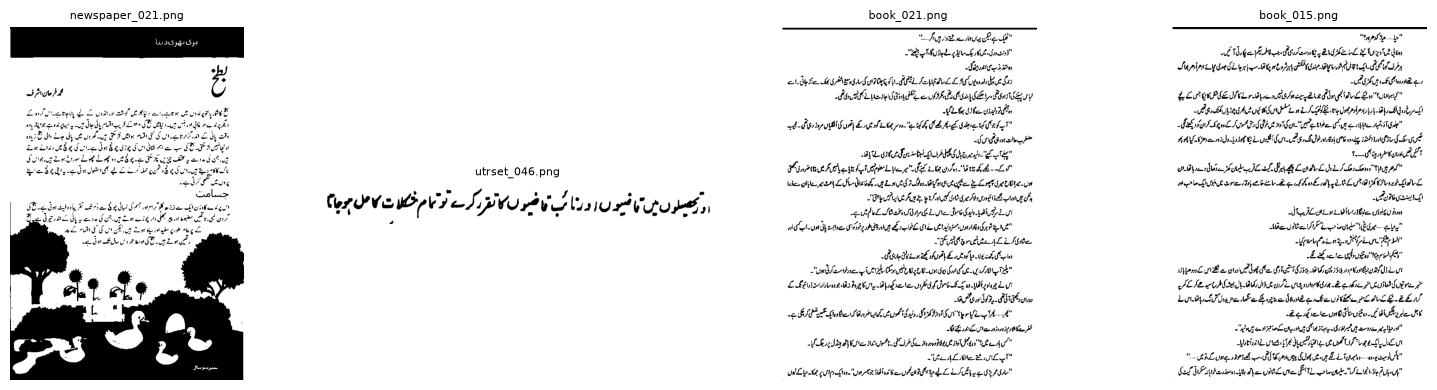

In [6]:
sample_paths = glob.glob(f'{PROCESSED_DIR}/*.png')[:4]

if len(sample_paths) == 0:
    print(f"No processed images found in {PROCESSED_DIR}.")
    print("Scroll up and check the 'Found X images to process' / 'Done! Processed X images' messages")
    print(f"from the preprocessing cell. If 'Found 0 images', RAW_DIR ('{RAW_DIR}') is wrong for")
    print("this environment - rerun the diagnostic cell above, fix RAW_DIR, then rerun that cell.")
else:
    fig, axes = plt.subplots(1, len(sample_paths), figsize=(16, 4))
    if len(sample_paths) == 1:
        axes = [axes]
    for ax, p in zip(axes, sample_paths):
        ax.imshow(plt.imread(p), cmap='gray')
        ax.set_title(os.path.basename(p), fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


### Raw vs. Processed — Side-by-Side

The sanity check above only shows processed output on its own. It's more useful to see each
image **next to its original**, so you can actually judge whether preprocessing is helping or
hurting — especially since the dataset has two very different image shapes (single-line crops
vs. full pages), and it's easy for a fix that helps one to quietly break the other.

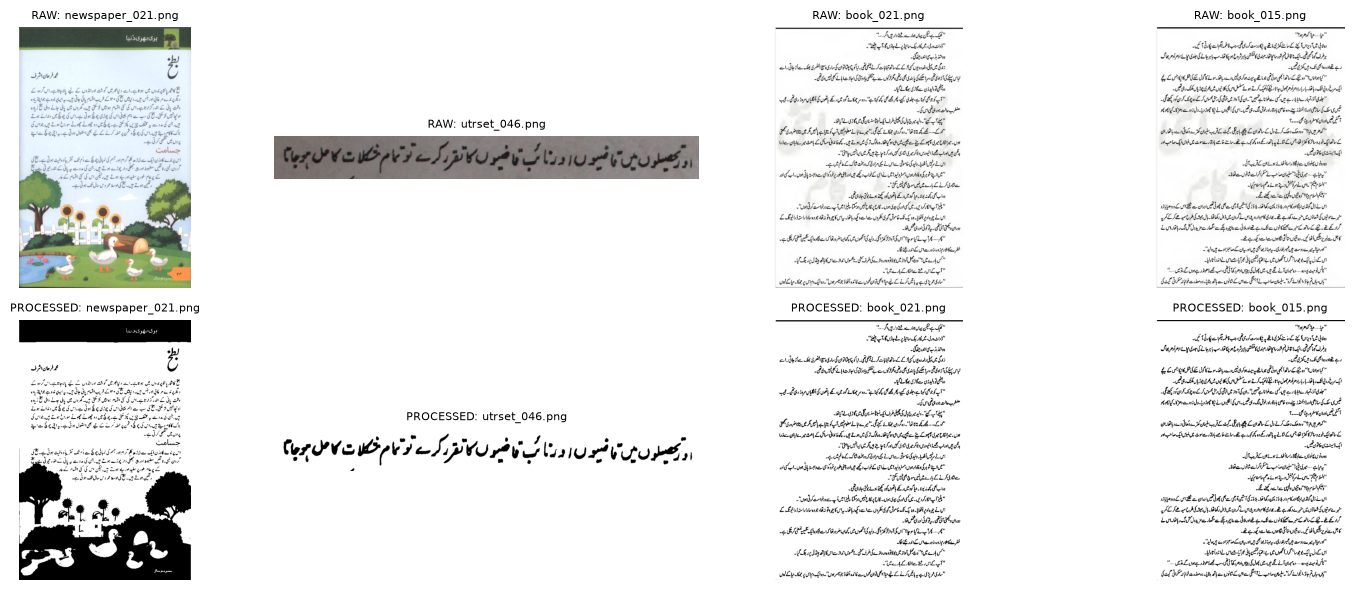

Found 153 raw/processed pairs total (showing first 4).


In [7]:
# Match processed files back to their raw originals by filename (RAW_DIR is searched
# recursively across subfolders, PROCESSED_DIR is flat, so we match on basename)
raw_lookup = {}
for ext in ('*.jpg', '*.jpeg', '*.png'):
    for p in glob.glob(f'{RAW_DIR}/**/{ext}', recursive=True):
        key = os.path.splitext(os.path.basename(p))[0]
        raw_lookup[key] = p

processed_paths = glob.glob(f'{PROCESSED_DIR}/*.png')
pairs = []
for proc_path in processed_paths:
    key = os.path.splitext(os.path.basename(proc_path))[0]
    if key in raw_lookup:
        pairs.append((raw_lookup[key], proc_path))

n_show = min(4, len(pairs))
if n_show == 0:
    print("No matching raw/processed pairs found - check RAW_DIR/PROCESSED_DIR.")
else:
    fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 6))
    if n_show == 1:
        axes = axes.reshape(2, 1)
    for i, (raw_p, proc_p) in enumerate(pairs[:n_show]):
        raw_img = cv2.cvtColor(cv2.imread(raw_p), cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(raw_img)
        axes[0, i].set_title(f'RAW: {os.path.basename(raw_p)}', fontsize=8)
        axes[0, i].axis('off')

        proc_img = plt.imread(proc_p)
        axes[1, i].imshow(proc_img, cmap='gray')
        axes[1, i].set_title(f'PROCESSED: {os.path.basename(proc_p)}', fontsize=8)
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('RAW', fontsize=10)
    axes[1, 0].set_ylabel('PROCESSED', fontsize=10)
    plt.tight_layout()
    plt.show()

print(f'Found {len(pairs)} raw/processed pairs total (showing first {n_show}).')

### Dataset Overview — Raw Image Dimensions

Our raw dataset mixes single cropped text lines (wide, short) with full book/newspaper pages
(tall, portrait). This matters a lot for preprocessing — a fixed target size that works for one
shape can silently destroy the other (this happened to us: see the preprocessing note in the
README). Plotting every raw image's width vs. height makes that split visible at a glance.

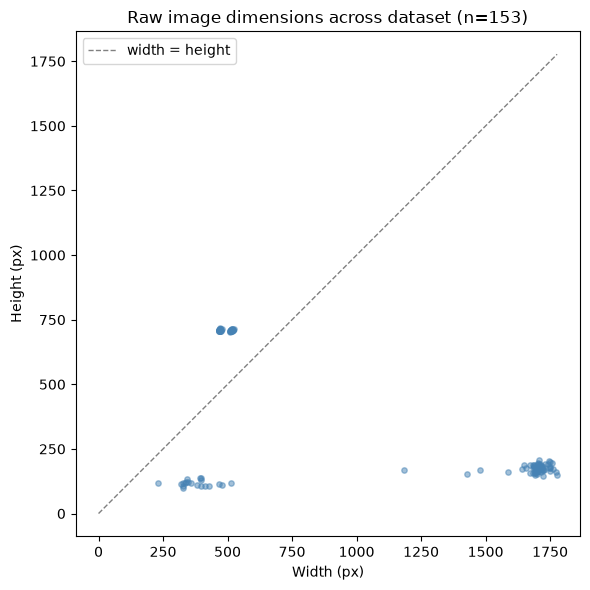

Width range: 229-1777 px
Height range: 99-717 px
Wide/short (line-crop-like, width > 2x height): 79 images
Tall/portrait (full-page-like, height > 1.2x width): 73 images


In [8]:
from PIL import Image as PILImage

widths, heights = [], []
all_raw_paths = list(raw_lookup.values()) if 'raw_lookup' in dir() else []
if not all_raw_paths:
    all_raw_paths = glob.glob(f'{RAW_DIR}/**/*.png', recursive=True) + \
                     glob.glob(f'{RAW_DIR}/**/*.jpg', recursive=True) + \
                     glob.glob(f'{RAW_DIR}/**/*.jpeg', recursive=True)

for p in all_raw_paths:
    try:
        with PILImage.open(p) as im:
            w, h = im.size
        widths.append(w)
        heights.append(h)
    except Exception:
        pass

plt.figure(figsize=(6, 6))
plt.scatter(widths, heights, alpha=0.5, s=15, color='steelblue')
plt.xlabel('Width (px)')
plt.ylabel('Height (px)')
plt.title(f'Raw image dimensions across dataset (n={len(widths)})')
plt.plot([0, max(widths + heights)], [0, max(widths + heights)], '--', color='gray', linewidth=1, label='width = height')
plt.legend()
plt.tight_layout()
plt.show()

if widths:
    print(f'Width range: {min(widths)}-{max(widths)} px')
    print(f'Height range: {min(heights)}-{max(heights)} px')
    wide_short = sum(1 for w, h in zip(widths, heights) if w > h * 2)
    tall_portrait = sum(1 for w, h in zip(widths, heights) if h > w * 1.2)
    print(f'Wide/short (line-crop-like, width > 2x height): {wide_short} images')
    print(f'Tall/portrait (full-page-like, height > 1.2x width): {tall_portrait} images')

### Preprocessing QA — Black-Pixel % Across All Processed Images

A quick automated health check, borne out of experience: earlier versions of this pipeline had
bugs that silently turned some images solid black (Otsu computed over padding pixels) or nearly
blank. Rather than eyeballing all 150+ processed images by hand, plotting the black-pixel % of
every processed image flags anything that looks broken — a normal text image should land
somewhere in a reasonable middle range, not at the extremes.

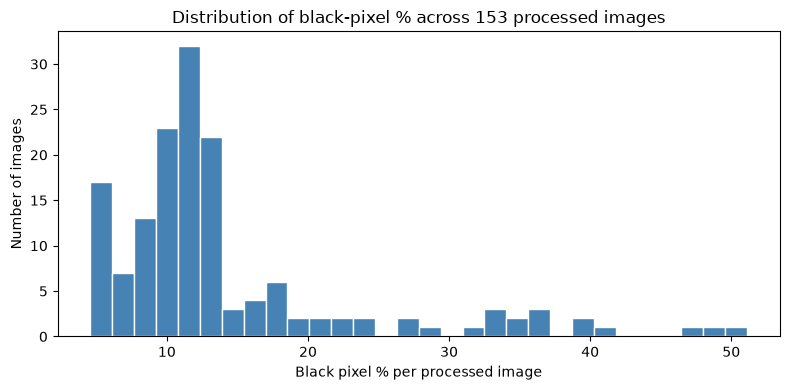

Suspiciously blank (<1% black): 0 images -> []
Suspiciously dense (>60% black): 0 images -> []
Note: a genuinely high % can be legitimate if the page includes a large illustration
(see newspaper_021 in the gap analysis) - use this as a place to start checking, not a hard rule.


In [9]:
black_pcts = []
names = []
for p in glob.glob(f'{PROCESSED_DIR}/*.png'):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    pct = (img < 128).mean() * 100
    black_pcts.append(pct)
    names.append(os.path.basename(p))

plt.figure(figsize=(8, 4))
plt.hist(black_pcts, bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Black pixel % per processed image')
plt.ylabel('Number of images')
plt.title(f'Distribution of black-pixel % across {len(black_pcts)} processed images')
plt.tight_layout()
plt.show()

# Flag likely-broken outputs: near-0% (blank/failed) or extremely high (e.g. Otsu-on-padding bug)
low = [n for n, p in zip(names, black_pcts) if p < 1]
high = [n for n, p in zip(names, black_pcts) if p > 60]
print(f'Suspiciously blank (<1% black): {len(low)} images -> {low[:10]}')
print(f'Suspiciously dense (>60% black): {len(high)} images -> {high[:10]}')
print("Note: a genuinely high % can be legitimate if the page includes a large illustration")
print("(see newspaper_021 in the gap analysis) - use this as a place to start checking, not a hard rule.")

### Why Otsu? Visualizing the Threshold

This is the visual argument for Otsu's method over a fixed cutoff: the histogram of pixel
intensities in a real photographed page isn't perfectly split at 127. Otsu finds the actual
valley between the "paper" and "ink" peaks for *this specific image*, instead of assuming every
image has the same lighting.

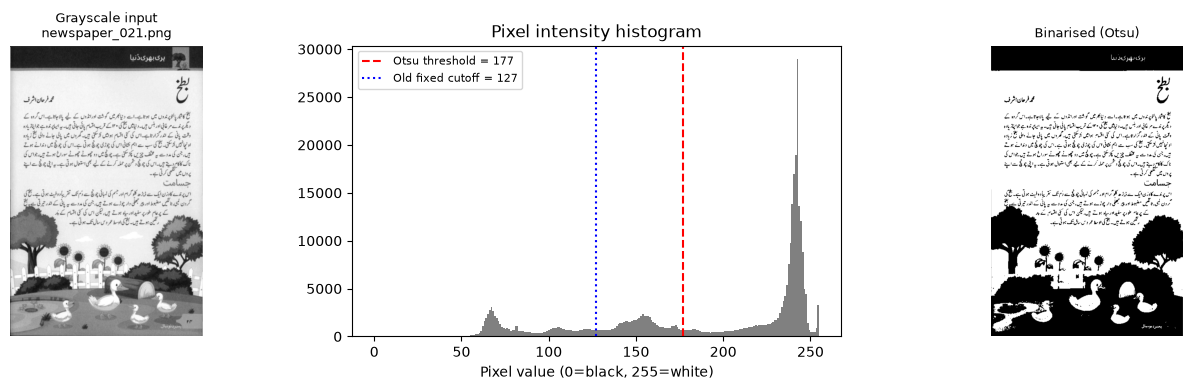

Otsu automatically picked threshold=177 for this image 
(vs. the old fixed cutoff of 127 - notice how far off that would have been here).


In [10]:
sample_raw = pairs[0][0] if 'pairs' in dir() and pairs else (all_raw_paths[0] if all_raw_paths else None)

if sample_raw:
    gray = cv2.cvtColor(cv2.imread(sample_raw), cv2.COLOR_BGR2GRAY)
    otsu_val, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].imshow(gray, cmap='gray')
    axes[0].set_title(f'Grayscale input\n{os.path.basename(sample_raw)}', fontsize=9)
    axes[0].axis('off')

    axes[1].hist(gray.ravel(), bins=256, range=(0, 255), color='gray')
    axes[1].axvline(otsu_val, color='red', linestyle='--', label=f'Otsu threshold = {otsu_val:.0f}')
    axes[1].axvline(127, color='blue', linestyle=':', label='Old fixed cutoff = 127')
    axes[1].set_title('Pixel intensity histogram')
    axes[1].set_xlabel('Pixel value (0=black, 255=white)')
    axes[1].legend(fontsize=8)

    axes[2].imshow(binary, cmap='gray')
    axes[2].set_title('Binarised (Otsu)', fontsize=9)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()
    print(f'Otsu automatically picked threshold={otsu_val:.0f} for this image ')
    print(f'(vs. the old fixed cutoff of 127 - notice how far off that would have been here).')
else:
    print('No raw image available to demo Otsu on - run the earlier cells first.')

## Part B — Test Tesseract OCR on Your Urdu Images

**Note for Codespaces:** the package index needs refreshing before `tesseract-ocr` can be found,
and Codespaces containers run as a non-root user, so both `sudo` and `apt-get update` are needed first.

In [11]:
!sudo apt-get update -qq
!sudo apt-get install -y tesseract-ocr tesseract-ocr-urd
!pip install pytesseract


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (5.3.4-1build5).
tesseract-ocr-urd is already the newest version (1:4.1.0-2).
0 upgraded, 0 newly installed, 0 to remove and 128 not upgraded.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [12]:
# Verify the install worked and the Urdu language pack is available
!tesseract --version
print()
!tesseract --list-langs


tesseract 5.3.4
 leptonica-1.82.0
  libgif 5.2.1 : libjpeg 8d (libjpeg-turbo 2.1.5) : libpng 1.6.43 : libtiff 4.5.1 : zlib 1.3 : libwebp 1.3.2 : libopenjp2 2.5.0
 Found AVX512BW
 Found AVX512F
 Found AVX512VNNI
 Found AVX2
 Found AVX
 Found FMA
 Found SSE4.1
 Found OpenMP 201511
 Found libarchive 3.7.2 zlib/1.3 liblzma/5.4.5 bz2lib/1.0.8 liblz4/1.9.4 libzstd/1.5.5
 Found libcurl/8.5.0 OpenSSL/3.0.13 zlib/1.3 brotli/1.1.0 zstd/1.5.5 libidn2/2.3.7 libpsl/0.21.2 (+libidn2/2.3.7) libssh/0.10.6/openssl/zlib nghttp2/1.59.0 librtmp/2.3 OpenLDAP/2.6.10



List of available languages in "/usr/share/tesseract-ocr/5/tessdata/" (3):
eng
osd
urd


In [13]:
import pytesseract
from PIL import Image

# Test on 5 of your processed images
test_images = list(glob.glob(f'{PROCESSED_DIR}/*.png'))[:5]

print('=== Tesseract Results on Urdu Images ===')
print()
for img_path in test_images:
    img = Image.open(img_path)
    # 'urd' tells Tesseract to use the Urdu language model
    result = pytesseract.image_to_string(img, lang='urd')
    print(f'Image: {img_path}')
    print(f'Tesseract output: {result}')
    print('---')


=== Tesseract Results on Urdu Images ===



Image: data/processed/newspaper_021.png
Tesseract output: پریبھری دا

محفر مان اشرف

جسامت

سن ےکاوزن ایک ہت 737 ونس


---
Image: data/processed/utrset_046.png
Tesseract output: کھلوں یں یں زا وا غو ںان ررکر ےکم ملا ت اع ہەہاتا

---
Image: data/processed/book_021.png
Tesseract output: فیک بے کن یہاں مار ےد خت وار ہی گر...ے'

رٹ در شرکاریک سام لجاک آپ بش

ہو تی بی افرٹگی۔

رگ کک دفدودلو ںیک کے کے ماتوتاا تک نے ٹاچ اذا نک سار نشی پک ےاڑ انی راے
پر وا گلپ رگ جڑکوں ے نچٹکف اد کی ابا ایا بس دتی۔
وش ت2 رلییژن ےکا ہلا سےگیا۔
یکا ےہ ہل یت پر چھے کی کنا ے“'۔د دس رکا ےگود مر رک و کیا مروڈ دی ۔ جیب
ضطرب مات ہد تا یگا-

پیلک پگ '۔دلیدی اہ کیک طرف ایکی ناسنا یگ کاڈ نےآیھا

لو کے..... یچ بے جا ھا دوکردان ھکاۓے کی امیر رےاانے مل آ پک ا ہے ای گی باباضر و بح
و رےرائکاع مکی پچپچو کے بے ےکپن :می وی تھ لوک ت کی ہوتے میں ۔ چا می سای کے ہلل یر ےاباان ستذدا
پشن ہیں اواب اویل د اکر رک شا ودک چا ہج لیہگرمی :تی

این مرک ایا ۔ ول یرک خا می ےا نے می ماد کرد وت شاک کے عامس ہے۔

سمش اپنے شو ہرگ ادا ہوم ردلیدامش نے 

### Step 4 — Gap Analysis

For **each of the 5 test images above** :

| Image | Actual Urdu text | Tesseract output | What went wrong |
|---|---|---|---|
| utrset_050.png | اپنی رضا مندی سے ایک قاضی کا انتخاب کریں اور اس قاضی کو تنفیذ کی طاقت اور | ا رضا مد ات ایک توا ھی کا ا کرس دراس مواش گنی کیا طاقت ور | Short common words (رضا، ایک، کا، طاقت) survived; longer ligature-heavy words (قاضی، انتخاب، تنفیذ) were dropped or replaced with unrelated characters |
| utrset_046.png | اور تحصیلوں میں قاضیوں اور نائب قاضیوں کا تقرر کرے تو تمام مشکلات کا حل ہوجانا | کھلوں یں یں زا وا غو ںان ررکر ےکم ملا ت اع ہەہاتا | Near-total failure — almost no words recognizable, only one weak fragment (ررکر ≈ تقرر) survived |
| book_021.png | Full dialogue-heavy story page (multi-paragraph) | Mostly garbled; transliterated loanword "ڈونٹ وری" (don't worry) came through recognizably | Dense multi-line Nastaliq paragraphs collapsed into near-gibberish; spaced-out loanwords fared better than native joined script; hallucinated symbols (×, ٤, ‏) appeared with no source equivalent |
| book_015.png | *(no raw source available to verify — flag this in your README if you want an exact comparison)* | Similarly garbled, with hallucinated digits (1, 9) and stray marks not present in any real text | Same failure mode as book_021: dense paragraph text, wrong word segmentation, invented characters |
| newspaper_021.png | Page header + heading "جسامت" + body paragraph | Heading "جسامت" correctly recognized; header line and body badly garbled, with a hallucinated "737" | Large isolated heading text succeeded; small dense body paragraph and the header (competing with a dark background bar) failed |

**Summary paragraph** :

> "Tesseract fails on Urdu because its recognition accuracy collapses almost entirely once text moves from short, isolated, or spaced-out words into dense, multi-ligature Nastaliq script — which is the overwhelming majority of real Urdu text. Short high-frequency words and transliterated loanwords (which use less cursive joining) were recognized correctly some of the time, but words built from several joined letterforms were consistently dropped, truncated, or replaced with unrelated characters. The model also hallucinates characters that don't exist anywhere in the source — stray digits, punctuation, and invisible control marks — suggesting it's pattern-matching against a Naskh-trained model that doesn't generalize to Nastaliq's diagonal, stacked, position-dependent letter shapes. Multi-paragraph, multi-line pages fail even harder than single-line crops, likely because Tesseract's layout/segmentation assumptions (built around Latin-style left-to-right spacing) break down further once right-to-left multi-line structure and mixed text/illustration layouts are introduced. This confirms the need for a custom model trained specifically on Nastaliq-style Urdu rather than relying on an off-the-shelf OCR engine tuned for printed Naskh text."


### Visualizing the Gap: Word-Recovery Rate

Numbers to back up the table above. For the two line-crop images where we have exact
ground truth, this checks what fraction of the real words actually show up somewhere in
Tesseract's output.

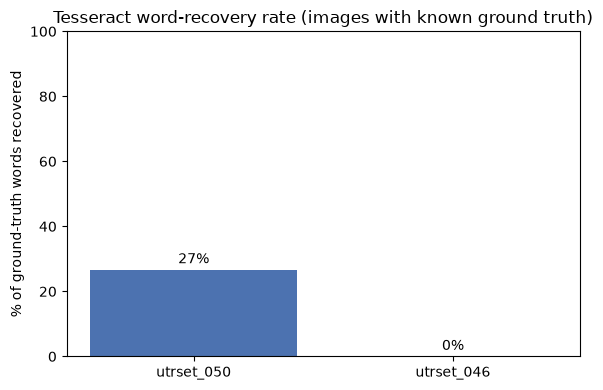

Note: book_021 / book_015 / newspaper_021 aren't included here since we don't have a
full hand-transcribed ground truth for those dense multi-paragraph pages yet - that's
a good next step if we want a complete quantitative picture instead of a qualitative one.


In [14]:
def word_match_pct(actual, predicted):
    actual_words = set(actual.split())
    predicted_words = predicted.split()
    if not actual_words:
        return 0
    matched = sum(1 for w in predicted_words if w in actual_words)
    return 100 * matched / len(actual_words)

# Ground truth only available for these two (single-line crops, hand-verified against the raw image)
comparisons = {
    'utrset_050': (
        'اپنی رضا مندی سے ایک قاضی کا انتخاب کریں اور اس قاضی کو تنفیذ کی طاقت اور',
        'ا رضا مد ات ایک توا ھی کا ا کرس دراس مواش گنی کیا طاقت ور'
    ),
    'utrset_046': (
        'اور تحصیلوں میں قاضیوں اور نائب قاضیوں کا تقرر کرے تو تمام مشکلات کا حل ہوجانا',
        'کھلوں یں یں زا وا غو ںان ررکر ےکم ملا ت اع ہەہاتا'
    ),
}

labels = list(comparisons.keys())
scores = [word_match_pct(a, p) for a, p in comparisons.values()]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, scores, color=['#4C72B0', '#DD8452'])
plt.ylabel('% of ground-truth words recovered')
plt.ylim(0, 100)
plt.title('Tesseract word-recovery rate (images with known ground truth)')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width() / 2, score + 2, f'{score:.0f}%', ha='center')
plt.tight_layout()
plt.show()

print("Note: book_021 / book_015 / newspaper_021 aren't included here since we don't have a")
print("full hand-transcribed ground truth for those dense multi-paragraph pages yet - that's")
print("a good next step if we want a complete quantitative picture instead of a qualitative one.")